In [1]:
import sionna.rt as rt
import mitsuba as mi
import numpy as np
import drjit as dr
import matplotlib.pyplot as plt


In [2]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return rt.PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [3]:
def paths_to_coverage_map(paths, is_mesh=False):
    """
    Converts paths into the equivalent coverage map values.
    The coverage map is assumed to be a ssquare.
    """
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    a_real, a_imag = paths.a
    a = a_real.numpy() + 1j*a_imag.numpy()

    # Transmit precoding
    # Assume default precoding
    # [num_rx, num_rx_ant, num_tx, num_paths]
    a /= np.sqrt(a.shape[3])
    a = np.sum(a, axis=3)

    # Sum energy of paths
    a = np.square(np.abs(a))
    # [num_rx, num_tx]
    a = np.sum(a, axis=(1, 3))

    # Swap dims
    # [num_tx, num_rx]
    a = a.T

    if not is_mesh:
        # Reshape to coverage map
        n = int(np.sqrt(a.shape[1]))
        shape = [a.shape[0], n, n]
        a = np.reshape(a, shape)

    return a

In [4]:
sim_params = dict(
    max_depth = 5,
    los = True,
    specular_reflection=True,
    diffuse_reflection=True,
    refraction=True
)

In [5]:
N = 100
vert_x, vert_y = np.meshgrid(
    np.linspace(0, 10, N),
    np.linspace(0, 10, N),
    indexing="xy")
# elevation = np.zeros_like(vert_x)
# elevation = np.exp(-((vert_x-5)**2 + (vert_y-5)**2)) / 5
elevation = (np.sin(2 * vert_x) + np.sin(2 * vert_y)) / 2 / 10
mesh = rt.utils.geometry.triangulate_elevation(mi.TensorXf(elevation), center=[0, 0, 0], size=[1, 1])
vertices = dr.reshape(mi.Point3f, mesh.vertex_positions_buffer(), (3, -1))

# Create scene
props = mi.Properties()
props["material"] = rt.RadioMaterial(
    name="lunar-highland",
    thickness=11,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)
# props["material"] = rt.ITURadioMaterial("mat", itu_type="concrete", thickness=10)
# props["material"] = rt.ITURadioMaterial("mat", itu_type="glass", thickness=1)
# props["material"] = rt.RadioMaterial("mat", thickness=10, relative_permittivity=100)
# Sionna requires bsdfs to be wrapped in HolderMaterial
props["material"] = rt.HolderMaterial(props)
mi_mesh = mi.Mesh(name="terrain",
                  vertex_count=mesh.vertex_count(),
                  face_count=mesh.face_count(), 
                  props=props)
mesh_params = mi.traverse(mesh)
mi_mesh_params = mi.traverse(mi_mesh)
mi_mesh_params["vertex_positions"] = dr.ravel(vertices)
mi_mesh_params["faces"] = mesh_params["faces"]
mi_mesh_params.update()
scene = rt.Scene(mi.load_dict({
    "type": "scene",
    "terrain": mi_mesh
}))

scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")
tx = rt.Transmitter(name="tx",
                #  position=mi.Point3f(0, 0, 0.1),
                 position=mi.Point3f(.2, .2, 0.1),
                 orientation=mi.Point3f(0,0,0))
tx.display_radius = 0.01
scene.add(tx)

In [6]:
# Compute the radio map
rm_solver = rt.RadioMapSolver()
rm = rm_solver(scene=scene,
               center=[0, 0, 0], 
               size=[1, 1],
               cell_size=[0.01, 0.01],
               # evaluate 5cm above the surface
               digital_elevation_model=mi.TensorXf(elevation) + 0.05,
               samples_per_tx=int(1e8),
               **sim_params)

# Check for NaN or Inf
assert not (dr.any(dr.isinf(rm.path_gain)) or dr.any(dr.isnan(rm.path_gain)))

# rm_solver = rt.RadioMapSolver()
# rm = rm_solver(
#     scene=scene,
#     center=[0, 0, 0], 
#     size=[1, 1],
#     cell_size=[0.005, 0.005],
#     # evaluate 1cm above the surface
#     digital_elevation_model=mi.TensorXf(elevation) + 0.01,
#     samples_per_tx=int(1e8),
#     max_depth=10,
#     los=True,
#     specular_reflection=True,
#     diffuse_reflection=True,
#     refraction=True
# )

2025-07-03 00:59:38.135 | INFO     | sionna.rt.radio_map_solvers.dem_radio_map:__init__:68 - Triangulating elevation with center [[0, 0, 0]] and size [[1, 1]]


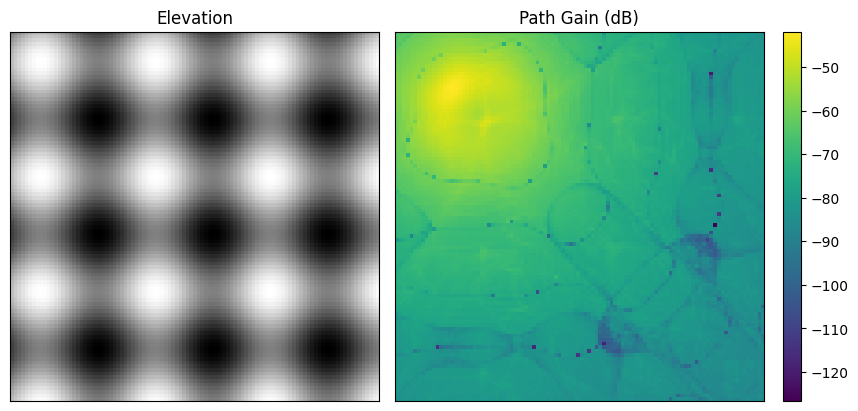

In [7]:
from matplotlib.colors import Normalize, LogNorm

fig, axs = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(8.5, 4)
axs[0].imshow(rm.elevation, cmap="gray")
mappable = axs[1].imshow(20 * np.log10(rm.path_gain[0]))
plt.colorbar(mappable)
axs[0].set_title("Elevation")
axs[1].set_title("Path Gain (dB)")
for ax in axs.flat:
    ax.set(xticks=[], yticks=[])
# pg = rm.path_gain.numpy().squeeze()
# qmin, qmax = np.quantile(pg, [0.05, 0.95])
# axs[0].imshow(rm.path_gain.numpy().squeeze(), norm="log")
# axs[1].imshow(rm.path_gain.numpy().squeeze(), norm=Normalize(qmin, qmax))
# axs[0].set_title("log")
# axs[1].set_title("norm")
# axs[1].imshow(elevation.numpy(), cmap="grey")

In [8]:
# Add receivers at the cell centers
# for i, pos in enumerate(rm.cell_centers.numpy().reshape(-1, 3)):
#     scene.remove(f"rx-{i}")
#     scene.add(rt.Receiver(name=f"rx-{i}",
#                         position=pos,
#                         display_radius=0.01,
#                         orientation=mi.Point3f(0, 0, 0)))

# # Compute radio map using the path solver
# scene.remove("triangulated_elevation")
# solver = rt.PathSolver()
# paths = solver(scene,
#                 samples_per_src = 10000,
#                 max_num_paths_per_src=int(1e8),
#                 **sim_params)
# a = paths_to_coverage_map(paths, is_mesh=True)[0]
# a = np.reshape(a, rm.cell_centers.numpy().shape[:2])
rm_mesh = rm_solver(scene=scene,
                    center=[0, 0, 0], 
                    size=[1, 1],
                    cell_size=[0.04, 0.04],
                    measurement_surface=rm.measurement_surface,
                    samples_per_tx=int(1e8),
                    **sim_params)

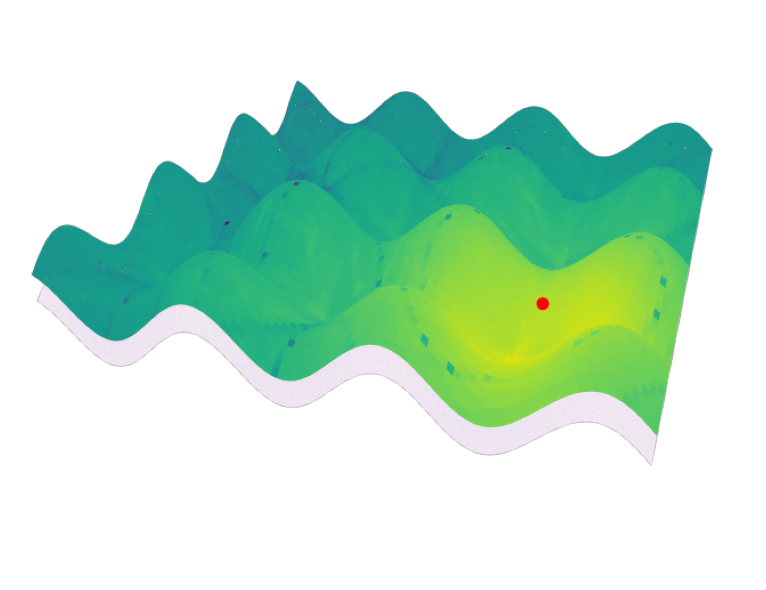

In [9]:
cam = rt.Camera(position=[-1, 0, 0.8], look_at=[0.3, 0.5, 0])
scene.render(camera=cam, show_devices=True, radio_map=rm);

(100, 100) (100, 100)


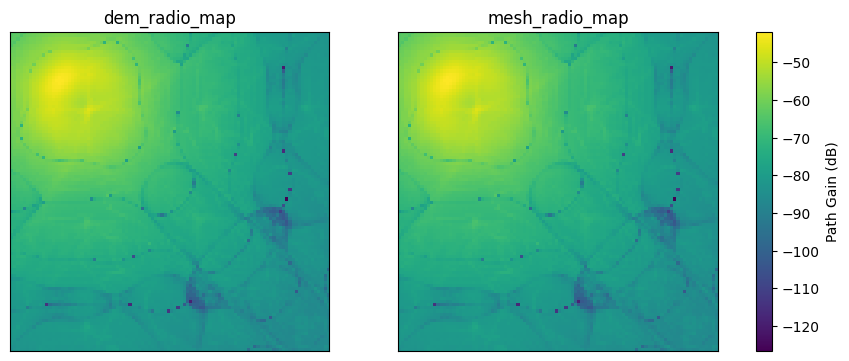

In [11]:
from sionna.rt.radio_map_solvers.dem_radio_map import _resample_tensor
from matplotlib.cm import ScalarMappable


meas_surf = rm_mesh.measurement_surface
faces = meas_surf.faces_buffer().numpy().reshape(-1, 3)
num_faces = meas_surf.face_count()
vertices = meas_surf.vertex_positions_buffer().numpy().reshape(-1, 3)
tris = vertices[faces]
v0 = tris[:, 0, :]
v1 = tris[:, 1, :]
v2 = tris[:, 2, :]
tri_areas = np.linalg.norm(np.cross(v1-v0, v2-v0), axis=-1) / 2
cell_areas = tri_areas[:num_faces//2] + tri_areas[num_faces//2:]

pg_mesh = rm_mesh.path_gain[0]
f1 = pg_mesh[:num_faces//2]
f2 = pg_mesh[num_faces//2:]
# this isn't going to get the perfect value but it will be close
pg_mesh = (f1 * tri_areas[:num_faces//2]/cell_areas + f2 * tri_areas[num_faces//2:]/cell_areas).numpy().reshape(N, N)
# pg_mesh = np.mean([f1, f2], axis=0).reshape(N-1, N-1)
# pg_mesh = _resample_tensor(mi.TensorXf(pg_mesh), mi.Point2u(N, N)).numpy()

pg = rm.path_gain[0]
print(pg_mesh.shape, pg.shape)

def dB(x, min_val=1e-12):
    return 20 * np.log10(np.maximum(min_val, np.abs(x)))

fig, axs = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(9, 3.5)
norm = Normalize(np.min([dB(pg), dB(pg_mesh)]), np.max([dB(pg), dB(pg_mesh)]))
axs[0].imshow(dB(pg), norm=norm)
axs[0].set(title="dem_radio_map")
axs[1].imshow(dB(pg_mesh), norm=norm)
axs[1].set(title="mesh_radio_map")
plt.colorbar(ScalarMappable(norm), ax=axs, label="Path Gain (dB)")
for ax in axs:
    ax.set(xticks=[], yticks=[])

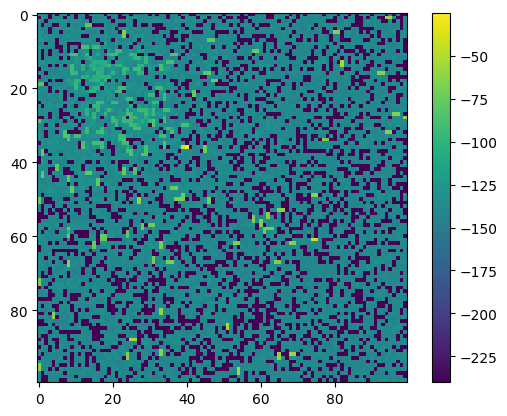

In [14]:
diff = np.abs(pg - pg_mesh)
plt.imshow(dB(diff / pg_mesh))
plt.colorbar()

In [ ]:
10 * np.log10(np.mean((np.abs(pg - pg_mesh) / np.abs(pg_mesh))**2))

np.float32(-96.67061)

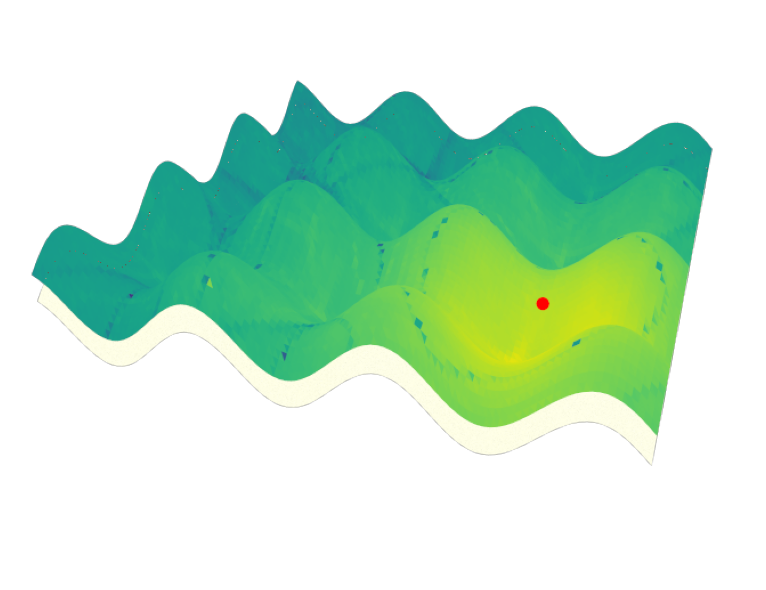

In [ ]:
cam = rt.Camera(position=[-1, 0, 0.8], look_at=[0.3, 0.5, 0])
scene.render(camera=cam, show_devices=True, radio_map=rm_mesh);

In [ ]:
assert False

AssertionError: 

In [ ]:
from matplotlib.cm import ScalarMappable

b = rm.path_gain[0].numpy()
fig, axs = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(7, 5)
a_db = 20 * np.log10(np.maximum(1e-12, np.abs(a)))
b_db = 20 * np.log10(np.maximum(1e-12, np.abs(b)))
norm = Normalize(np.min([a_db, b_db]), np.max([a_db, b_db]))
axs[0].imshow(a_db, norm=norm)
axs[1].imshow(b_db, norm=norm)
plt.colorbar(ScalarMappable(norm), ax=axs, location="bottom", label="Path Gain (dB)")
# axs[0].imshow(a)
# axs[1].imshow(b)
# Labels and formattiong
axs[0].set_title("Antenna Pairs")
axs[1].set_title("Radio Map")
for ax in axs:
    ax.set(xticks=[], yticks=[])

In [ ]:
plt.plot(np.ravel(a_db), label="a")
plt.plot(np.ravel(b_db), label="b")
plt.legend()

In [ ]:
plt.imshow(b_db - a_db)
plt.colorbar()
plt.title("Scaling offset b_db - a_db")
# plt.imshow(b/a)
# plt.colorbar()
# plt.title("Scaling factor b/a")

In [ ]:
# diff = np.mean(np.ravel(b / a)[:100])
# print(diff)
# plt.plot(np.ravel(a), label="a")
# plt.plot(np.ravel(b) / (N//2), label="b")
# plt.legend()
diff = np.mean(np.ravel(b_db - a_db)[:100])
print(diff)
magic = np.power(np.sqrt(2), N/100)* rm.cells_per_dim.x[0]#  * np.sqrt(2)
print(magic)
plt.plot(np.ravel(a_db), label="a")
plt.plot(np.ravel(b_db) - 28, label="b")
plt.legend()

In [ ]:
m = rm.measurement_surface
faces = np.array(m.faces_buffer()).reshape(-1, 3)
vertices = np.array(m.vertex_positions_buffer()).reshape(-1, 3)
tris = vertices[faces]
v0 = tris[:, 0, :]
v1 = tris[:, 1, :]
v2 = tris[:, 2, :]
area = 0
for i in range(tris.shape[0]):
    area += 1/2 * np.linalg.norm(np.cross(v1[i]-v0[i], v2[i]-v0[i]))
area

In [ ]:
# cam = rt.Camera(position=[-15, 10, 5], look_at=[5, 5, 2])
cam = rt.Camera(position=[-1, 0, 0.8], look_at=[0.3, 0.5, 0])
# cam = rt.Camera(position=[-1, 1, 1.5], look_at=[0.4, 0.5, 0.1])
rm.resample([0.05, 0.05])
scene.render(camera=cam, show_devices=True, radio_map=rm);
# scene.preview(show_devices=True, radio_map=rm);
# scene.preview(show_devices=True);

In [ ]:
# rm.resample([0.02, 0.02])
# rm.resample([0.05, 0.05])
scene.preview(show_devices=True, radio_map=rm);

In [ ]:
assert False

In [ ]:
nmse_db = 10*np.log10(np.mean( ((rm.path_gain[0]-a)/a)**2 ))

In [ ]:
nmse_db